In [19]:
import pandas as pd
import matplotlib.pyplot as plt


parks_df = pd.read_csv(r'C:\Users\opiej\ufo-analysis-capstone\ufo-analysis-capstone\data\national_parks.csv.csv', on_bad_lines='skip')
parks_df.head()

C:\Users\opiej\AppData\Local\Temp\ipykernel_21936\4175291497.py:5: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  parks_df = pd.read_csv(r'C:\Users\opiej\ufo-analysis-capstone\ufo-analysis-capstone\data\national_parks.csv.csv', on_bad_lines='skip')


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [20]:
parks_df.head()
parks_df.columns.tolist()


['datetime',
 'city',
 'state',
 'country',
 'shape',
 'duration (seconds)',
 'duration (hours/min)',
 'comments',
 'date posted',
 'latitude',
 'longitude']

In [21]:
parks_df.columns = parks_df.columns.str.strip().str.lower().str.replace(' ', '_')
parks_df.columns


Index(['datetime', 'city', 'state', 'country', 'shape', 'duration_(seconds)',
       'duration_(hours/min)', 'comments', 'date_posted', 'latitude',
       'longitude'],
      dtype='object')

In [22]:
parks_df.isna().sum()


datetime                    0
city                        0
state                    7409
country                 12365
shape                    2922
duration_(seconds)          2
duration_(hours/min)     3019
comments                   35
date_posted                 0
latitude                    0
longitude                   0
dtype: int64

In [23]:
parks_df.dropna(subset=['datetime', 'state', 'city'], inplace=True)


In [24]:
parks_df['datetime'] = pd.to_datetime(parks_df['datetime'], errors='coerce')

parks_df.dropna(subset=['datetime'], inplace=True)

parks_df['month'] = parks_df['datetime'].dt.month
parks_df['year'] = parks_df['datetime'].dt.year
parks_df['year_month'] = parks_df['datetime'].dt.to_period('M').astype(str)


In [25]:
parks_df['shape'] = parks_df['shape'].fillna('unknown')
parks_df['comments'] = parks_df['comments'].fillna('')


In [26]:
parks_df['datetime'] = pd.to_datetime(parks_df['datetime'], errors='coerce')
parks_df['month'] = parks_df['datetime'].dt.month


In [27]:
parks_monthly = parks_df.groupby(['state', 'month'])['city'].count().reset_index(name='park_sightings')


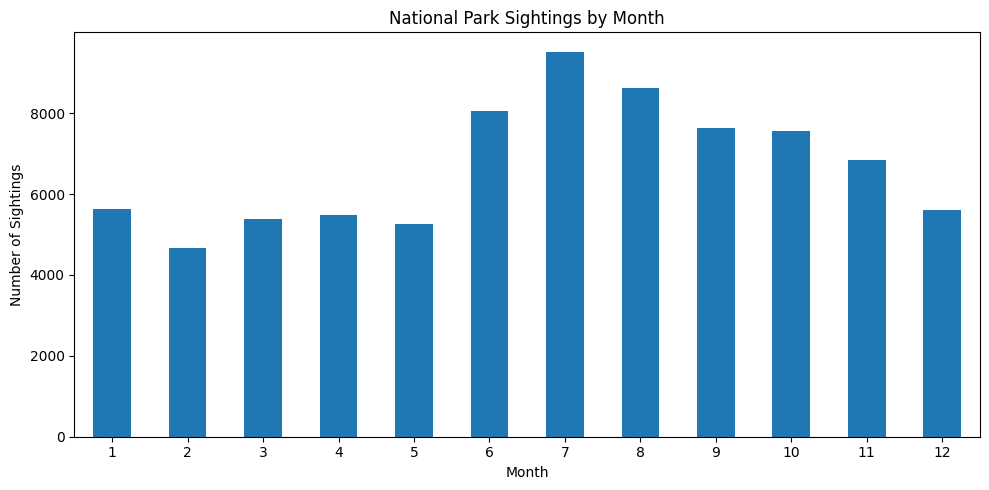

In [ ]:
parks_by_month = parks_df.groupby('month')['city'].count()

parks_by_month.plot(kind='bar', figsize=(10, 5))
plt.title('National Park Sightings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



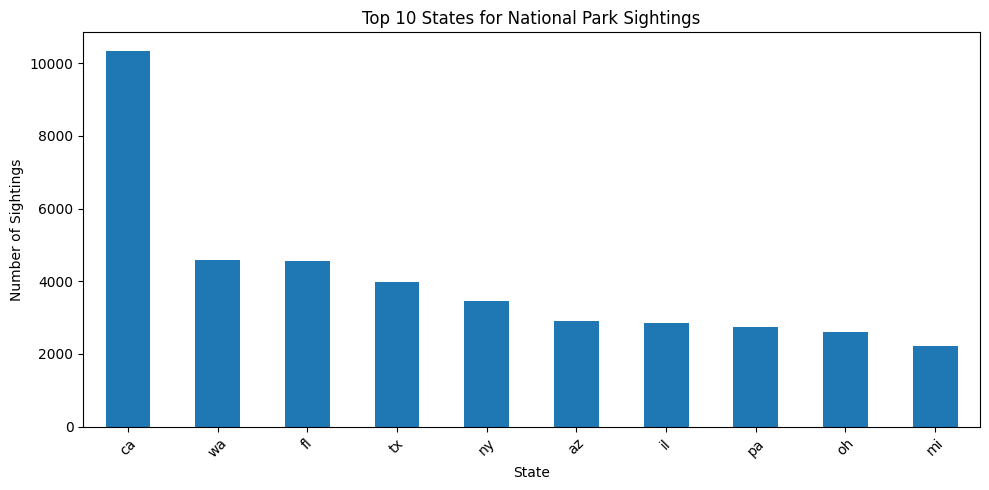

In [29]:
parks_by_state = parks_df.groupby('state')['city'].count().sort_values(ascending=False).head(10)

parks_by_state.plot(kind='bar', figsize=(10, 5))
plt.title('Top 10 States for National Park Sightings')
plt.xlabel('State')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


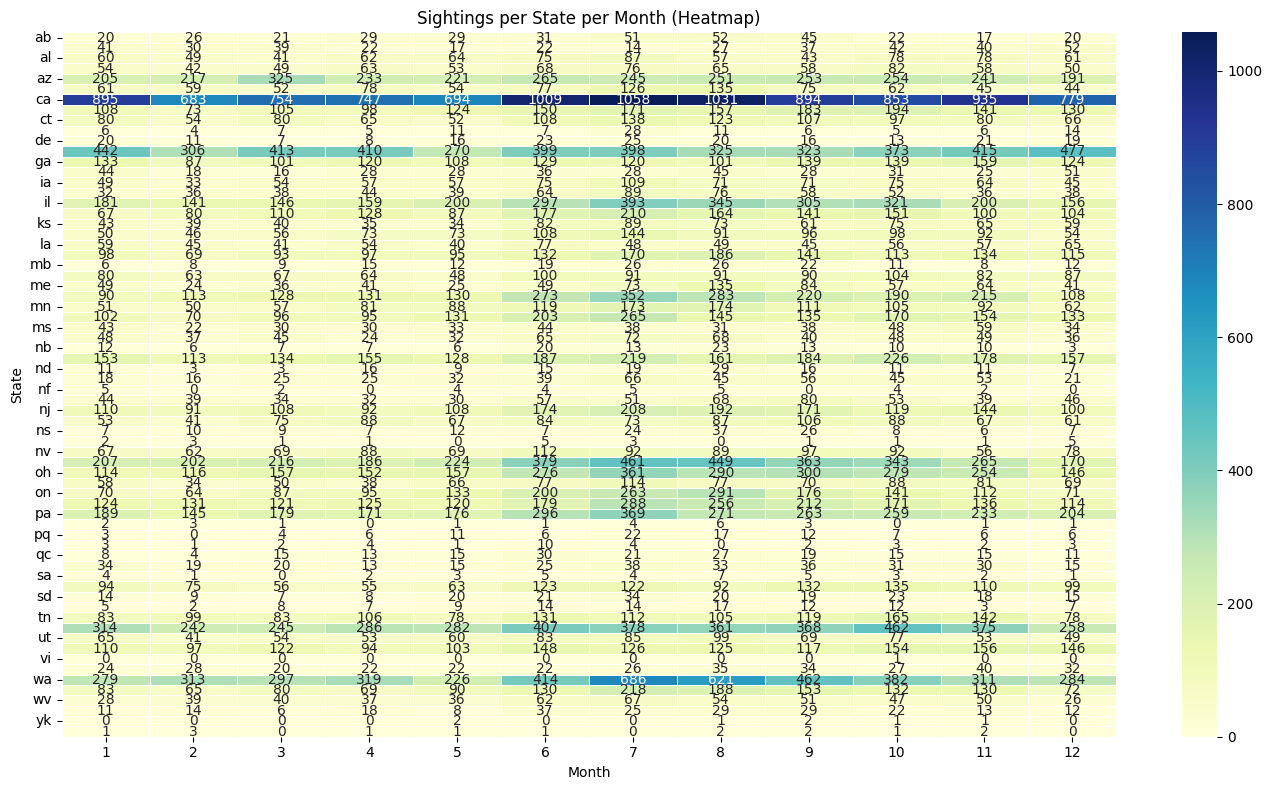

In [30]:
import seaborn as sns

heatmap_data = parks_df.groupby(['state', 'month'])['city'].count().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.5, annot=True, fmt='d')
plt.title('Sightings per State per Month (Heatmap)')
plt.xlabel('Month')
plt.ylabel('State')
plt.tight_layout()
plt.show()


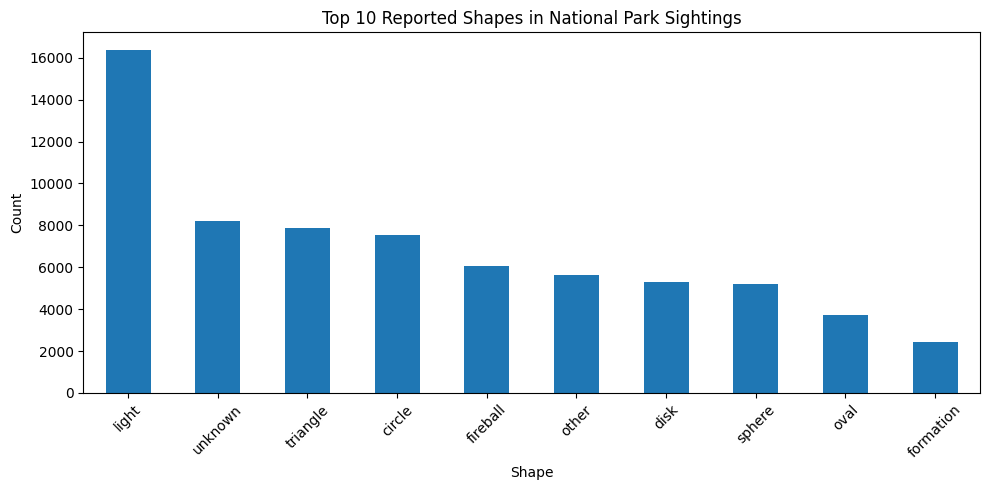

In [31]:
parks_df['shape'].value_counts().head(10).plot(kind='bar', figsize=(10, 5))
plt.title('Top 10 Reported Shapes in National Park Sightings')
plt.xlabel('Shape')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


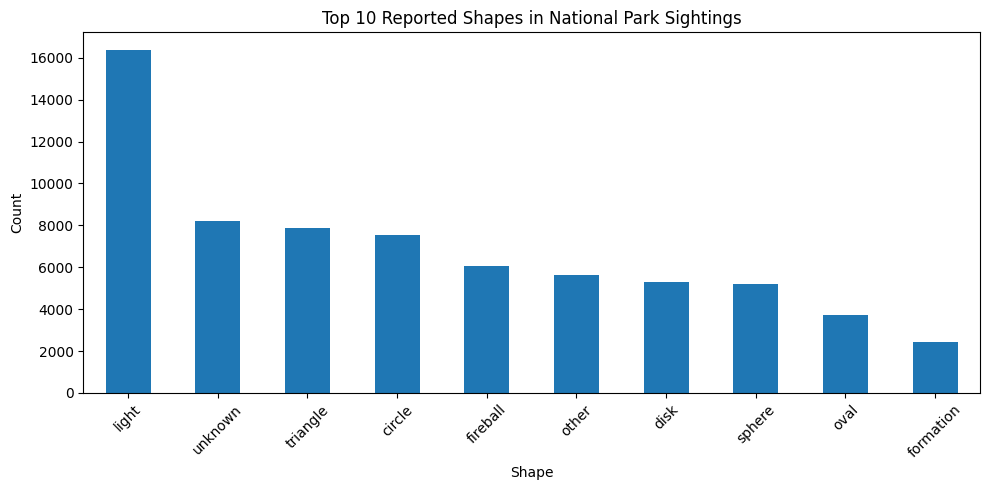

In [32]:
parks_df['shape'].value_counts().head(10).plot(kind='bar', figsize=(10, 5))
plt.title('Top 10 Reported Shapes in National Park Sightings')
plt.xlabel('Shape')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [34]:
parks_df.to_csv(r'C:\Users\opiej\ufo-analysis-capstone\ufo-analysis-capstone\data\national_parks_clean.csv')